In [1]:
import segmentation_models as sm

BACKBONE = 'resnet50'
preprocess_input = sm.get_preprocessing(BACKBONE)

# load your data
#x_train, y_train, x_val, y_val = load_data(...)

# preprocess input
#x_train = preprocess_input(x_train)
#x_val = preprocess_input(x_val)

# define model
model = sm.PSPNet(BACKBONE, classes=1,input_shape=(240, 240, 3), activation='sigmoid', encoder_weights='imagenet')
#model = sm.PSPNet(backbone_name='vgg16', input_shape=(None, None, 3), classes=1, activation='sigmoid', weights=None, encoder_weights='imagenet', encoder_freeze=False)

model.compile(
    'Adam',
    loss=sm.losses.bce_jaccard_loss,
    metrics=[sm.metrics.iou_score],
)

# fit model
# if you use data generator use model.fit_generator(...) instead of model.fit(...)
# more about `fit_generator` here: https://keras.io/models/sequential/#fit_generator


Segmentation Models: using `keras` framework.


In [2]:
#!pip install efficientnet
#!pip install classification-models-keras
#!pip install classification-models
#!pip install segmentation-models


In [3]:
#import segmentation_models as sm

#model = sm.Unet('resnet34', classes=1, activation='sigmoid')

In [4]:
import os
import numpy as np
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

#New generator with rotation and shear where interpolation that comes with rotation and shear are thresholded in masks.
#This gives a binary mask rather than a mask with interpolated values.
seed=24
batch_size= 8
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [5]:
#####################################################################
#Define the model. Experiment with various loss functions and accuracy metrics
# pip install focal-loss

#######################################


#Jaccard distance loss mimics IoU.
#from keras import backend as K
import tensorflow.keras.backend as K
def jaccard_distance_loss(y_true, y_pred, smooth=100):
    """
    Jaccard = (|X & Y|)/ (|X|+ |Y| - |X & Y|)
            = sum(|A*B|)/(sum(|A|)+sum(|B|)-sum(|A*B|))

    The jaccard distance loss is usefull for unbalanced datasets. This has been
    shifted so it converges on 0 and is smoothed to avoid exploding or disapearing
    gradient.

    Ref: https://en.wikipedia.org/wiki/Jaccard_index

    @url: https://gist.github.com/wassname/f1452b748efcbeb4cb9b1d059dce6f96
    @author: wassname
    """
    intersection = K.sum(K.sum(K.abs(y_true * y_pred), axis=-1))
    sum_ = K.sum(K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1))
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return (1 - jac) * smooth

#Dice metric can be a great metric to track accuracy of semantic segmentation.
def dice_metric(y_pred, y_true):
    intersection = K.sum(K.sum(K.abs(y_true * y_pred), axis=-1))
    union = K.sum(K.sum(K.abs(y_true) + K.abs(y_pred), axis=-1))
    # if y_pred.sum() == 0 and y_pred.sum() == 0:
    #     return 1.0

    return 2*intersection / union





In [6]:
import os
#os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input

from tensorflow.keras.layers import AveragePooling2D, GlobalAveragePooling2D, UpSampling2D, Reshape, Dense

from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
import tensorflow as tf

In [7]:
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import UpSampling2D, Conv2D, Activation, BatchNormalization, Concatenate, AveragePooling2D
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50
import keras
img_size = (224, 224)
num_classes = 1



In [8]:
import os
#os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import cv2
from glob import glob
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Recall, Precision
#from metrics import dice_loss, dice_coef, iou

In [9]:
metrics = ["accuracy",
           tf.keras.metrics.AUC(),
           tf.keras.metrics.SensitivityAtSpecificity(0.5),
           tf.keras.metrics.SpecificityAtSensitivity(0.5),
          dice_metric,
          jaccard_distance_loss]
model.compile(loss="binary_crossentropy", optimizer=Adam(1e-4), metrics=metrics)

In [10]:
callbacks = [
    EarlyStopping(patience=10, verbose=1),
    ReduceLROnPlateau(factor=0.1, patience=5, min_lr=0.00001, verbose=1),
   tf.keras.callbacks.ModelCheckpoint(
    'wholemodel.keras',
    monitor='val_loss',
    verbose=0,
    save_best_only=False,
    #save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None
),
    CSVLogger("dataResUnet.csv"),
    TensorBoard(log_dir='./logs')
]

In [13]:
import os
batch_size=8

num_train_imgs = len(os.listdir("C:\\recent caltech\\journal 2 GA for segmentation\\original split\\all images\\train images\\train"))

steps_per_epoch1 = num_train_imgs //batch_size
print(steps_per_epoch1)

num_train_imgs1 = len(os.listdir("C:\\recent caltech\\journal 2 GA for segmentation\\original split\\output splitted\\test\\images\\images\\"))

steps_per_epoch2 = num_train_imgs1 //batch_size
print(steps_per_epoch2)

749
362


In [14]:
img_height,img_width=240,240
#from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator


input_imgen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   rotation_range=5.,
                                   horizontal_flip = True)

test_imgen = ImageDataGenerator(rescale = 1./255)



def generate_generator_multiple(generator,dir1, dir4,color_mode, batch_size, img_height,img_width):
    genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          shuffle=False,
                                          seed=7)

    genY1 = generator.flow_from_directory(dir4,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          color_mode='grayscale',
                                          shuffle=False,
                                          seed=7)
    while True:
            X1i = genX1.__next__()

            XYi = genY1.__next__()
            yield X1i, XYi  #Yield both images and their mutual label

def generate_generator_testing(generator,dir1,color_mode, batch_size, img_height,img_width):
    genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          shuffle=False,
                                          seed=7)



    while True:
            X1i = genX1.__next__()
            #XYi = genY1.next()
            yield X1i  #Yield both images and their mutual label


In [15]:
batch_size=8
img_height=240
img_width=240

inputgenerator=generate_generator_multiple(generator=input_imgen,
                                           dir1="C:\\recent caltech\\journal 2 GA for segmentation\\original split\\all images\\train images",
                                           
                                           dir4="C:\\recent caltech\\journal 2 GA for segmentation\\original split\\all masks\\train masks",
                                           
                                           batch_size=batch_size,
                                           img_height=img_height,
                                           color_mode='grayscale',
                                           img_width=img_width)       
     
valgenerator=generate_generator_multiple(generator=test_imgen,
                                          dir1="C:\\recent caltech\\journal 2 GA for segmentation\\original split\\output splitted\\test\\images\\",
                                        
                                          dir4="C:\\recent caltech\\journal 2 GA for segmentation\\original split\\output splitted\\test\\masks\\",
                                          batch_size=batch_size,
                                          color_mode='grayscale',
                                          img_height=img_height,
                                          img_width=img_width)              
          


In [16]:
callbacks = [EarlyStopping(monitor='val_loss' , patience=5 , restore_best_weights=True)]

In [17]:
results=model.fit(inputgenerator,
                        steps_per_epoch=steps_per_epoch1,
                        epochs =20,
                        validation_data = valgenerator,
                        validation_steps = steps_per_epoch2,
                        callbacks=callbacks ,
                        #use_multiprocessing=True,
                        #shuffle=False
                           )

Found 5994 images belonging to 1 classes.
Found 5994 images belonging to 1 classes.
Epoch 1/20
749/749 [==============================] - ETA: 0s - loss: 0.1607 - accuracy: 0.8924 - auc: 0.9479 - sensitivity_at_specificity: 0.9861 - specificity_at_sensitivity: 0.9926 - dice_metric: 0.6590 - jaccard_distance_loss: 50.0174Found 2897 images belonging to 1 classes.
Found 2897 images belonging to 1 classes.
749/749 [==============================] - 215s 256ms/step - loss: 0.1607 - accuracy: 0.8924 - auc: 0.9479 - sensitivity_at_specificity: 0.9861 - specificity_at_sensitivity: 0.9926 - dice_metric: 0.6590 - jaccard_distance_loss: 50.0174 - val_loss: 0.1877 - val_accuracy: 0.8894 - val_auc: 0.9462 - val_sensitivity_at_specificity: 0.9834 - val_specificity_at_sensitivity: 0.9923 - val_dice_metric: 0.5486 - val_jaccard_distance_loss: 61.5796
Epoch 2/20
749/749 [==============================] - 197s 263ms/step - loss: 0.1134 - accuracy: 0.9108 - auc: 0.9674 - sensitivity_at_specificity: 0.982

In [18]:
"""
model.fit(
   x=x_train,
   y=y_train,
   batch_size=16,
   epochs=100,
   validation_data=(x_val, y_val),
)
"""

'\nmodel.fit(\n   x=x_train,\n   y=y_train,\n   batch_size=16,\n   epochs=100,\n   validation_data=(x_val, y_val),\n)\n'

In [19]:
import pandas as pd
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,accuracy,auc,sensitivity_at_specificity,specificity_at_sensitivity,dice_metric,jaccard_distance_loss,val_loss,val_accuracy,val_auc,val_sensitivity_at_specificity,val_specificity_at_sensitivity,val_dice_metric,val_jaccard_distance_loss
6,0.080053,0.921938,0.979460,0.981708,0.999863,0.828690,29.060659,0.083200,0.931957,0.976879,0.975963,0.999806,0.820928,30.152195
9,0.074600,0.923467,0.981998,0.983084,0.999928,0.841375,27.209785,0.084688,0.931802,0.975595,0.970655,0.999850,0.826475,29.331453
11,0.070960,0.924695,0.983384,0.983945,0.999941,0.848048,26.209026,0.089329,0.930955,0.973095,0.965984,0.999867,0.825388,29.441854
7,0.077794,0.922846,0.980549,0.982286,0.999869,0.833946,28.296757,0.090420,0.929967,0.973612,0.969423,0.999797,0.813048,31.208666
5,0.083831,0.920791,0.978248,0.981798,0.999813,0.821018,30.158148,0.094245,0.928421,0.972646,0.969921,0.999714,0.799912,33.040276
10,0.072929,0.923865,0.982722,0.983627,0.999936,0.844727,26.710667,0.096324,0.929081,0.970311,0.959766,0.999868,0.807050,32.017361
8,0.075510,0.923590,0.981523,0.982948,0.999890,0.838019,27.701925,0.096408,0.928825,0.970980,0.961533,0.999854,0.811220,31.369143
3,0.093401,0.917935,0.974601,0.981453,0.999533,0.800393,33.043549,0.101222,0.926356,0.971215,0.969541,0.999695,0.786658,34.786968
1,0.113448,0.910777,0.967412,0.982464,0.998656,0.759219,38.510429,0.109822,0.922352,0.968358,0.980386,0.999276,0.748447,39.812336
4,0.087829,0.919462,0.976823,0.981549,0.999726,0.812816,31.315966,0.109888,0.924019,0.966616,0.955902,0.999673,0.779575,35.679489


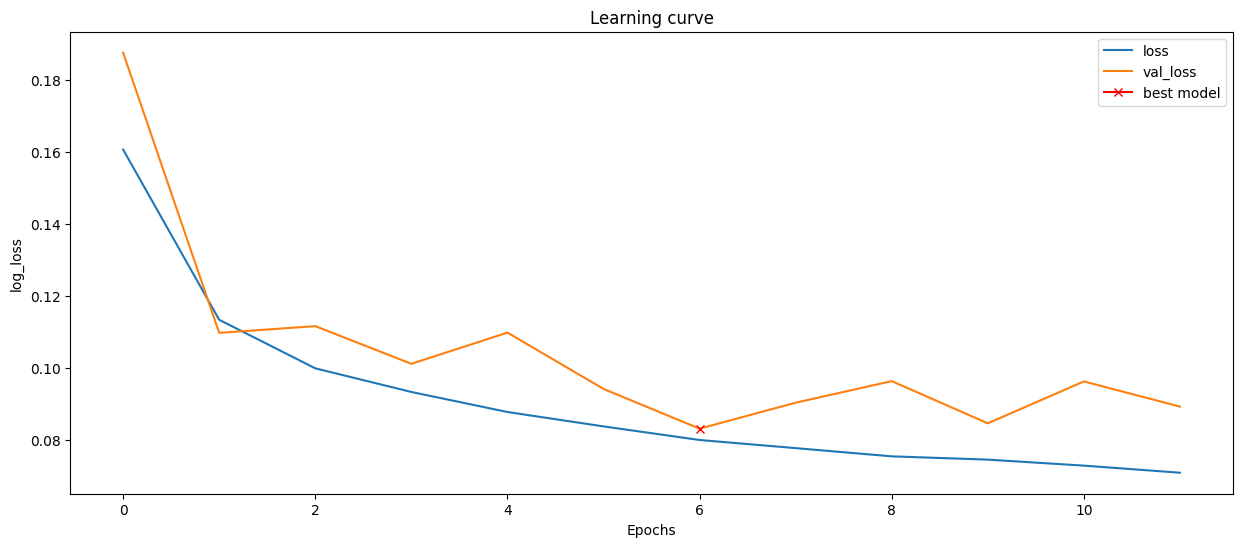

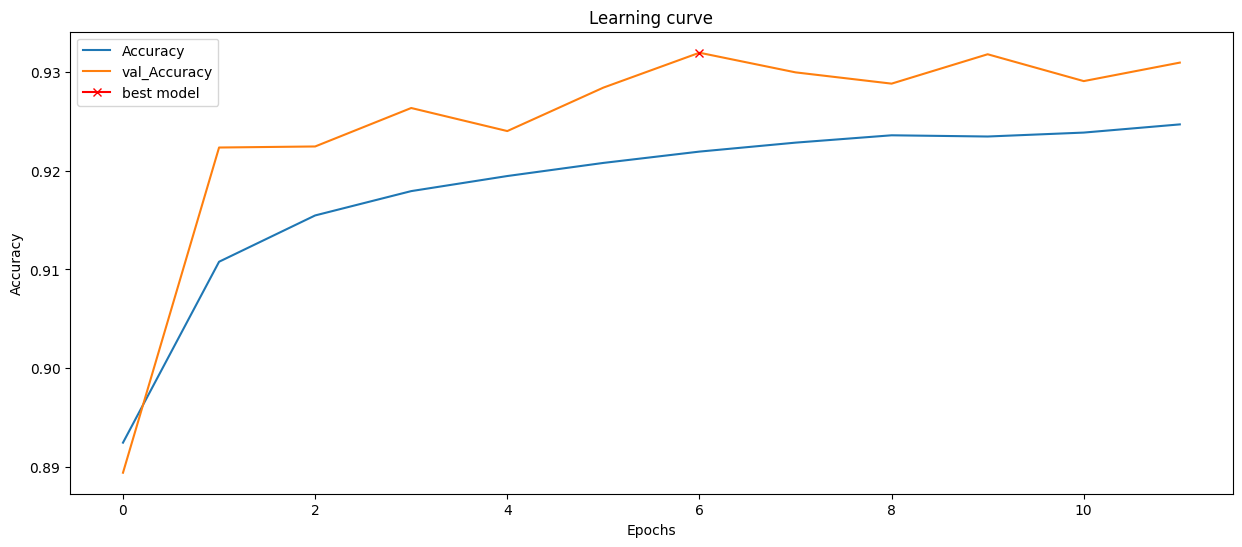

In [20]:
plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["loss"], label="loss")
plt.plot(results.history["val_loss"], label="val_loss")
plt.plot(np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["accuracy"], label="Accuracy")
plt.plot(results.history["val_accuracy"], label="val_Accuracy")
plt.plot(np.argmax(results.history["val_accuracy"]), np.max(results.history["val_accuracy"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();


In [22]:
model.save('PSPNet.h5')

In [20]:
import keras

model = keras.models.load_model("C:\\recent caltech\\journal 2 GA for segmentation\\original split\\PSPNet.h5", compile = False)
#model = keras.models.load_model('\\model.h5', compile = False)

METRICS =  ["accuracy",
           tf.keras.metrics.AUC(),
           tf.keras.metrics.SensitivityAtSpecificity(0.5),
           tf.keras.metrics.SpecificityAtSensitivity(0.5),
          dice_metric,
          jaccard_distance_loss]

model.compile(optimizer = keras.optimizers.Adam(learning_rate=1e-4),
              loss = 'binary_crossentropy',
              metrics = METRICS
             )

In [21]:
def generate_generator_multiple(generator,dir1, dir4,color_mode, batch_size, img_height,img_width):
    genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          shuffle=False, 
                                          seed=7)
   
    genY1 = generator.flow_from_directory(dir4,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          color_mode='grayscale',
                                          shuffle=False, 
                                          seed=7)
    while True:
            X1i = genX1.next()
            
            XYi = genY1.next()
            yield X1i, XYi 

def generate_generator_testing(generator,dir1,color_mode, batch_size, img_height,img_width):
    genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size = batch_size,
                                          shuffle=False, 
                                          seed=7)
    
   
    
    while True:
            X1i = genX1.next()
            #XYi = genY1.next()
            yield X1i  

In [22]:
import cv2
img_height,img_width=224,224
generator = ImageDataGenerator(rescale = 1./255)

#dir1="C:\\recent caltech\\journal 2 GA for segmentation\\new dataset images\\Woodpeckers bird-20240902T214132Z-001\\"
dir1="C:\\recent caltech\\deeplab3++\\big data 90 10\\test images"

genX1 = generator.flow_from_directory(dir1,
                                          target_size = (img_height,img_width),
                                          class_mode = None,
                                          batch_size =1,
                                          shuffle=False, 
                                          seed=seed)
for i in range(100):
    #img, label = dir_It.next()
    img1=genX1.next()
    print(img1.shape)   #  (1,256,256,3)
    output_image= model.predict(img1) 
    #generated_image=predict[0]
    #plt.imshow(x)
    #plt.savefig('C:\\recent caltech\\deeplab3++\\raw mobilenet\\oneshot mobilenet masks\\'+str(i)+'.png')
    #plt.imshow(img1[0])
    #generated_image = (generated_image * 255).astype(np.uint8)

    output_image = np.squeeze(output_image)  # Remove batch dimension if necessary

    # Ensure pixel values are in the correct range (0-255 for uint8)
    output_image = (output_image * 255).astype(np.uint8)

    # Save the image
    cv2.imwrite('C:\\recent caltech\\journal 2 GA for segmentation\\produced_images\\Linknet\\'+str(i)+'.png', output_image)
"""
for i in range(100):
    #img, label = dir_It.next()
    img1=genX1.next()
    print(img1.shape)   #  (1,256,256,3)
    predict = model.predict(img1) 
    x=predict[0]
    plt.imshow(x)
    plt.savefig('C:\\recent caltech\\journal 2 GA for segmentation\\new dataset images\\fcn32\\'+str(i)+'.png')
    #plt.savefig('C:\\recent caltech\\journal 2 GA for segmentation\\produced_images\\predicted_fcn32\\'+str(i)+'.png')
    plt.imshow(img1[0])
    #plt.savefig('C:\\recent caltech\\journal 2 GA for segmentation\\produced_images\\original\\'+str(i)+'png')
"""    


Found 590 images belonging to 1 classes.
(1, 224, 224, 3)
1/1 [==============================] - 1s 1s/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 71ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 63ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 54ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 65ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 49ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 53ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 49ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 48ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 51ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 47ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 48ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 54ms/step
(1, 224, 224, 3)
1/1 [==============================] - 0s 51ms/

"\nfor i in range(100):\n    #img, label = dir_It.next()\n    img1=genX1.next()\n    print(img1.shape)   #  (1,256,256,3)\n    predict = model.predict(img1) \n    x=predict[0]\n    plt.imshow(x)\n    plt.savefig('C:\\recent caltech\\journal 2 GA for segmentation\\new dataset images\\fcn32\\'+str(i)+'.png')\n    #plt.savefig('C:\\recent caltech\\journal 2 GA for segmentation\\produced_images\\predicted_fcn32\\'+str(i)+'.png')\n    plt.imshow(img1[0])\n    #plt.savefig('C:\\recent caltech\\journal 2 GA for segmentation\\produced_images\\original\\'+str(i)+'png')\n"